In [1]:
import ROOT
print(ROOT.__version__)

import numpy as np
import matplotlib.pyplot as plt

ROOT.gROOT.SetBatch(True)

plt.rcParams["figure.figsize"] = (8,5)

6.36.04


In [2]:
MU_TRUE = 1.0
SIGMA_TRUE = 0.05

N_EVENTS = 1000
N_TOYS = 500

In [3]:
x = ROOT.RooRealVar(
    "x",
    "x",
    0.5,
    1.5
)

In [4]:
mu_true = ROOT.RooRealVar(
    "mu_true",
    "mu_true",
    MU_TRUE
)

sigma_true = ROOT.RooRealVar(
    "sigma_true",
    "sigma_true",
    SIGMA_TRUE,
    1e-6,
    1.0
)

pdf_true = ROOT.RooGaussian(
    "pdf_true",
    "pdf_true",
    x,
    mu_true,
    sigma_true
)
print(pdf_true)

RooGaussian::pdf_true[ x=x mean=mu_true sigma=sigma_true ] = 1



In [5]:
toy_data = pdf_true.generate(
    ROOT.RooArgSet(x),
    N_EVENTS
)

In [6]:
toy_np = []

for i in range(toy_data.numEntries()):

    toy_np.append(
        toy_data.get(i).getRealValue("x")
    )

toy_np = np.array(toy_np)

toy_np[:10]

array([1.04994664, 0.97826178, 1.03908981, 0.99849736, 1.04121318,
       0.99716413, 0.9549562 , 0.99626478, 1.00039561, 0.97946184])

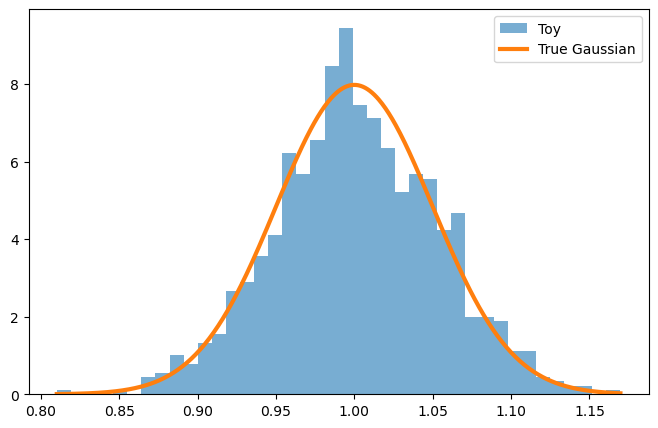

In [7]:
plt.hist(
    toy_np,
    bins=40,
    density=True,
    alpha=0.6,
    label="Toy"
)

xx = np.linspace(
    toy_np.min(),
    toy_np.max(),
    500
)

yy = (
    1/(SIGMA_TRUE*np.sqrt(2*np.pi))
    *
    np.exp(
        -(xx-MU_TRUE)**2
        /(2*SIGMA_TRUE**2)
    )
)

plt.plot(
    xx,
    yy,
    lw=3,
    label="True Gaussian"
)

plt.legend()

plt.show()

In [8]:
mu = ROOT.RooRealVar(
    "mu",
    "mu",
    1.0,
    0.8,
    1.2
)

sigma = ROOT.RooRealVar(
    "sigma",
    "sigma",
    0.05,
    0.001,
    0.2
)

pdf_fit = ROOT.RooGaussian(
    "pdf_fit",
    "pdf_fit",
    x,
    mu,
    sigma
)

In [9]:
fit_result = pdf_fit.fitTo(
    toy_data,
    ROOT.RooFit.Save(True),
    ROOT.RooFit.PrintLevel(-1)
)

[#1] INFO:Fitting -- RooAbsPdf::fitTo(pdf_fit_over_pdf_fit_Int[x]) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- using generic CPU library compiled with no vectorizations
[#1] INFO:Fitting -- Creation of NLL object took 13.6839 ms
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_pdf_fit_over_pdf_fit_Int[x]_pdf_trueData) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization


In [10]:
mu_fit = mu.getVal()
mu_err = mu.getError()

sigma_fit = sigma.getVal()
sigma_err = sigma.getError()

print("mu_fit    =", mu_fit)
print("mu_err    =", mu_err)

print()

print("sigma_fit =", sigma_fit)
print("sigma_err =", sigma_err)

mu_fit    = 1.0013409345283397
mu_err    = 0.0016409632217803671

sigma_fit = 0.05189239460881648
sigma_err = 0.0011603078304534623


In [11]:
pull_mu = (
    mu_fit - MU_TRUE
) / mu_err

pull_sigma = (
    sigma_fit - SIGMA_TRUE
) / sigma_err

print("Pull(mu)    =", pull_mu)
print("Pull(sigma) =", pull_sigma)

Pull(mu)    = 0.8171630604157423
Pull(sigma) = 1.6309418579696255


In [12]:
pull_mu_list = []

pull_sigma_list = []

mu_fit_list = []

sigma_fit_list = []

In [13]:
for itoy in range(N_TOYS):

    toy = pdf_true.generate(
        ROOT.RooArgSet(x),
        N_EVENTS
    )

    mu = ROOT.RooRealVar(
        "mu",
        "mu",
        1.0,
        0.8,
        1.2
    )

    sigma = ROOT.RooRealVar(
        "sigma",
        "sigma",
        0.05,
        0.001,
        0.2
    )
    
    pdf = ROOT.RooGaussian(
        "pdf",
        "pdf",
        x,
        mu,
        sigma
    )

    mu.setVal(1.0)
    sigma.setVal(0.05)

    result = pdf.fitTo(
        toy,
        ROOT.RooFit.Save(),
        ROOT.RooFit.PrintLevel(-1)
    )

    mu_fit = mu.getVal()
    mu_err = mu.getError()

    sigma_fit = sigma.getVal()
    sigma_err = sigma.getError()

    pull_mu_list.append(
        (mu_fit-MU_TRUE)/mu_err
    )

    pull_sigma_list.append(
        (sigma_fit-SIGMA_TRUE)/sigma_err
    )

    mu_fit_list.append(
        mu_fit
    )

    sigma_fit_list.append(
        sigma_fit
    )

[#1] INFO:Fitting -- RooAbsPdf::fitTo(pdf_over_pdf_Int[x]) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- Creation of NLL object took 211.459 μs
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_pdf_over_pdf_Int[x]_pdf_trueData) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: deactivating const optimization
[#1] INFO:Fitting -- RooAbsPdf::fitTo(pdf_over_pdf_Int[x]) fixing normalization set for coefficient determination to observables in data
[#1] INFO:Fitting -- Creation of NLL object took 97.042 μs
[#1] INFO:Fitting -- RooAddition::defaultErrorLevel(nll_pdf_over_pdf_Int[x]_pdf_trueData) Summation contains a RooNLLVar, using its error level
[#1] INFO:Minimization -- RooAbsMinimizerFcn::setOptimizeConst: activating const optimization
[#1] INFO:Minimization -- RooAbsMin

In [14]:
pull_mu = np.array(
    pull_mu_list
)

pull_sigma = np.array(
    pull_sigma_list
)

mu_fit_array = np.array(
    mu_fit_list
)

sigma_fit_array = np.array(
    sigma_fit_list
)

In [15]:
print(
    "Mean Pull(mu) =",
    np.mean(pull_mu)
)

print(
    "Width Pull(mu) =",
    np.std(pull_mu,ddof=1)
)

print()

print(
    "Mean Pull(sigma) =",
    np.mean(pull_sigma)
)

print(
    "Width Pull(sigma) =",
    np.std(pull_sigma,ddof=1)
)

Mean Pull(mu) = -0.017823821395161716
Width Pull(mu) = 1.0509045545653004

Mean Pull(sigma) = -0.010415388799700264
Width Pull(sigma) = 1.0661045383154706


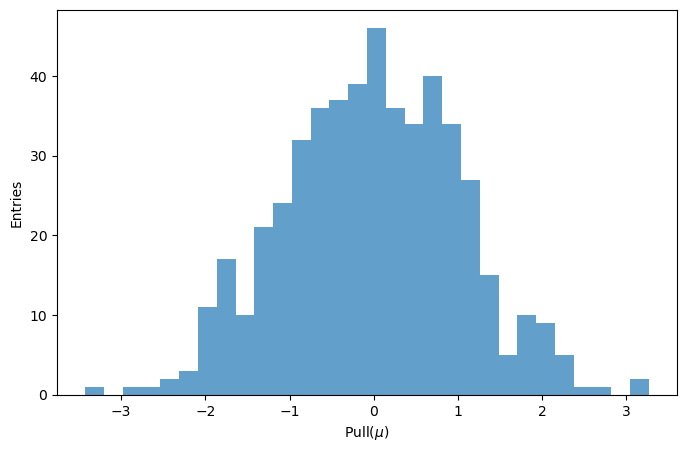

In [16]:
plt.hist(
    pull_mu,
    bins=30,
    alpha=0.7
)

plt.xlabel(r"Pull($\mu$)")
plt.ylabel("Entries")

plt.show()

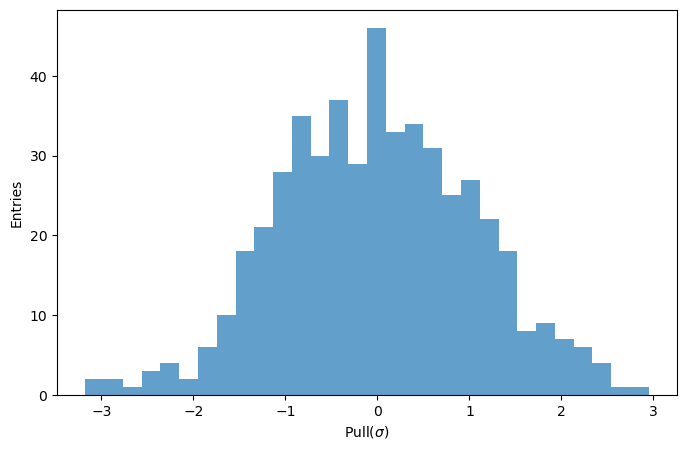

In [17]:
plt.hist(
    pull_sigma,
    bins=30,
    alpha=0.7
)

plt.xlabel(r"Pull($\sigma$)")
plt.ylabel("Entries")

plt.show()

In [18]:
print(
    "Average fitted mean =",
    np.mean(mu_fit_array)
)

print(
    "Average fitted sigma =",
    np.mean(sigma_fit_array)
)

Average fitted mean = 0.999971038478075
Average fitted sigma = 0.050016721156872994


In [19]:
def gauss(x, A, mu, sigma):

    return A*np.exp(
        -(x-mu)**2/(2*sigma**2)
    )

counts_mu, bins_mu = np.histogram(
    pull_mu,
    bins=30
)

centers_mu = 0.5*(bins_mu[1:] + bins_mu[:-1])

from scipy.optimize import curve_fit

p0 = [
    counts_mu.max(),
    np.mean(pull_mu),
    np.std(pull_mu, ddof=1)
]

popt_mu, pcov_mu = curve_fit(
    gauss,
    centers_mu,
    counts_mu,
    p0=p0
)

A_mu, mean_mu_fit, sigma_mu_fit = popt_mu

print("Gaussian Fit to UML Pull(mu)")
print("Mean  =", mean_mu_fit)
print("Sigma =", sigma_mu_fit)

Gaussian Fit to UML Pull(mu)
Mean  = -0.003140607683428978
Sigma = 1.0662902504101717


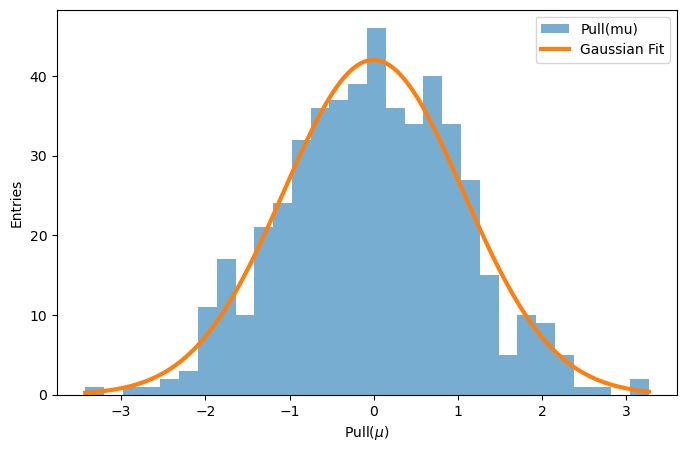

In [20]:
xfit = np.linspace(
    bins_mu[0],
    bins_mu[-1],
    1000
)

plt.hist(
    pull_mu,
    bins=30,
    alpha=0.6,
    label="Pull(mu)"
)

plt.plot(
    xfit,
    gauss(xfit,*popt_mu),
    lw=3,
    label="Gaussian Fit"
)

plt.xlabel(r"Pull($\mu$)")
plt.ylabel("Entries")

plt.legend()

plt.show()

In [21]:
counts_sig, bins_sig = np.histogram(
    pull_sigma,
    bins=30
)

centers_sig = 0.5*(bins_sig[1:] + bins_sig[:-1])

p0 = [
    counts_sig.max(),
    np.mean(pull_sigma),
    np.std(pull_sigma, ddof=1)
]

popt_sig, pcov_sig = curve_fit(
    gauss,
    centers_sig,
    counts_sig,
    p0=p0
)

A_sig, mean_sig_fit, sigma_sig_fit = popt_sig

print("Gaussian Fit to UML Pull(sigma)")
print("Mean  =", mean_sig_fit)
print("Sigma =", sigma_sig_fit)

Gaussian Fit to UML Pull(sigma)
Mean  = -0.029473843706880172
Sigma = 1.0863410844826151


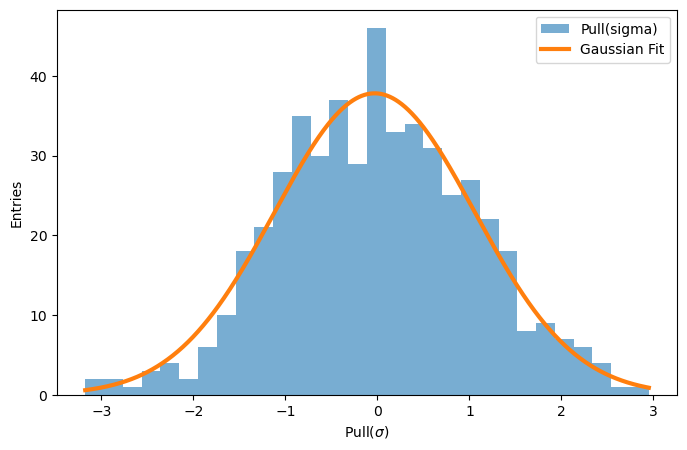

In [22]:
xfit = np.linspace(
    bins_sig[0],
    bins_sig[-1],
    1000
)

plt.hist(
    pull_sigma,
    bins=30,
    alpha=0.6,
    label="Pull(sigma)"
)

plt.plot(
    xfit,
    gauss(xfit,*popt_sig),
    lw=3,
    label="Gaussian Fit"
)

plt.xlabel(r"Pull($\sigma$)")
plt.ylabel("Entries")

plt.legend()

plt.show()